<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/dollar_cost_averaging_bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dollar Cost Averaging for Bitcoin with Python

### Introduction

Dollar-cost averaging (DCA) is an investing strategy where you invest a fixed amount of money at regular intervals, regardless of whether the price of the asset is high or low.

The idea is:
- When prices are low, your fixed amount buys more units.
- When prices are high, it buys fewer units.
- Over time, this can reduce the impact of market volatility compared to investing a lump sum all at once.

### Install and Import Libraries

`yfinance` gives us historical BTC prices from Yahoo Finance.
`pandas` helps organize data into tables.
`matplotlib` and `plotly` are used for charts.

In [16]:
# Install required libraries
%pip install yfinance plotly --quiet

# Data handling
import pandas as pd
import numpy as np

# Download financial data
import yfinance as yf

# Visualization libraries
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Better chart appearance
plt.style.use("ggplot")

### Download Bitcoin Historical Data

We request: BTC priced in USD (`BTC-USD`) and data from 2018 to 2026. The result is stored in a Pandas DataFrame called `btc`.

In [17]:
# Download Bitcoin historical market data
btc = yf.download(
    "BTC-USD",
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

# Display first rows
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


### Explore the Dataset

Before building the strategy, it is important to inspect the dataset: check available columns,verify date ranges, and understand the structure.

In [18]:
# View dataset information
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2922 entries, 2018-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   2922 non-null   float64
 1   (High, BTC-USD)    2922 non-null   float64
 2   (Low, BTC-USD)     2922 non-null   float64
 3   (Open, BTC-USD)    2922 non-null   float64
 4   (Volume, BTC-USD)  2922 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.0 KB


In [19]:
# Summary statistics
btc.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,2922.000000,2922.000000,2922.000000,2922.000000,2.922000e+03
mean,37273.879198,37989.148836,36466.453941,37250.112668,3.021526e+10
std,32214.288778,32730.284254,31645.469979,32204.330305,2.200128e+10
min,3236.761719,3275.377930,3191.303467,3236.274658,2.923670e+09
25%,9475.868408,9653.321289,9264.668945,9472.798828,1.528955e+10
50%,27334.937500,27820.822266,26865.267578,27301.943359,2.609323e+10
75%,57418.280273,58533.908203,55857.645508,57415.968750,3.975322e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [20]:
# Check for missing values
btc.isnull().sum()

,,0
Price,Ticker,
Close,BTC-USD,0
High,BTC-USD,0
Low,BTC-USD,0
Open,BTC-USD,0
Volume,BTC-USD,0


### Visualize Bitcoin Price History

This chart helps us understand Bitcoin’s historical price movement over time. We use the `Close` price because it represents the final market price for each trading day.

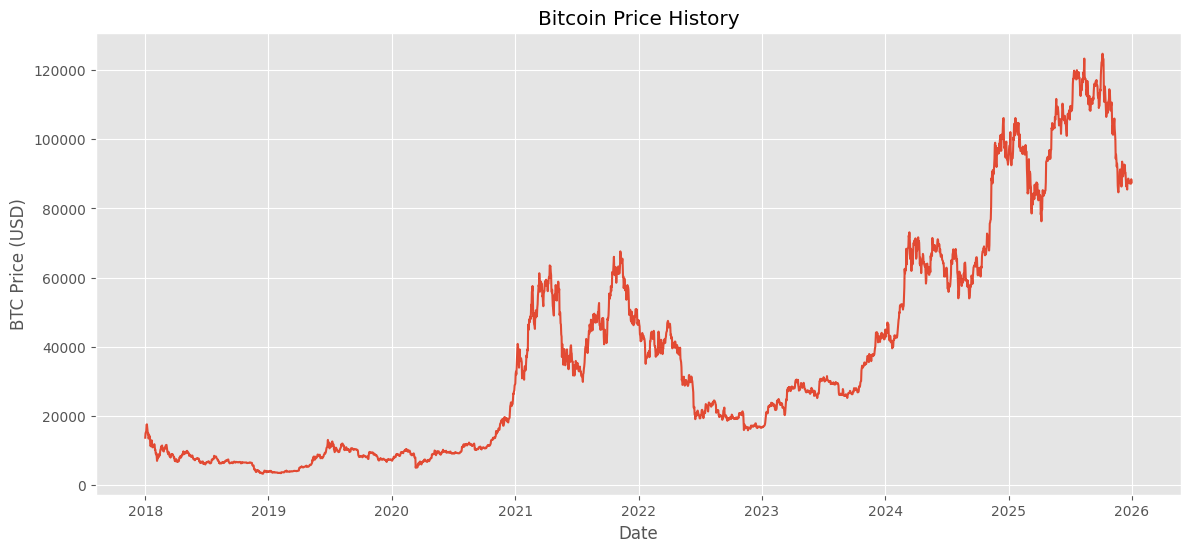

In [21]:
# Create a price history chart
plt.figure(figsize=(14,6))

# Plot Bitcoin closing price
plt.plot(
    btc.index,
    btc["Close"]
)

# Add labels and title
plt.title("Bitcoin Price History")
plt.xlabel("Date")
plt.ylabel("BTC Price (USD)")

plt.show()

### Configure the DCA Strategy

Now we define the DCA strategy rules.
In this example:
- we invest a fixed amount every week,
- regardless of Bitcoin price.
This simulates consistent long-term investing.

In [22]:
# Amount invested every week
weekly_investment = 100

print(f"Weekly investment amount: ${weekly_investment}")

Weekly investment amount: $100


### Prepare Weekly Bitcoin Prices

Bitcoin prices are available daily, but our strategy invests once per week.
We resample the data to:
- one price per week,
- using the final closing price every Monday.

In [23]:
# Convert daily prices into weekly prices
weekly_prices = btc["Close"].resample("W-MON").last()

# Display first weekly prices
weekly_prices.head()

Ticker,BTC-USD
Date,
2018-01-01,13657.200195
2018-01-08,15170.099609
2018-01-15,13819.799805
2018-01-22,10931.400391
2018-01-29,11296.400391


### Simulate Dollar Cost Averaging

For every week:
- Invest a fixed amount
- Calculate BTC purchased
- Track cumulative BTC owned
- Track total money invested
- Calculate portfolio value over time

In [24]:
# Create a new DataFrame for strategy simulation
dca = pd.DataFrame(index=weekly_prices.index)

# Store BTC price
dca["BTC_Price"] = weekly_prices

# Fixed weekly investment
dca["Investment"] = weekly_investment

# BTC purchased each week
dca["BTC_Bought"] = (
    dca["Investment"] / dca["BTC_Price"]
)

# Running total BTC accumulated
dca["Total_BTC"] = (
    dca["BTC_Bought"].cumsum()
)

# Running total money invested
dca["Total_Invested"] = (
    dca["Investment"].cumsum()
)

# Current portfolio value
dca["Portfolio_Value"] = (
    dca["Total_BTC"] * dca["BTC_Price"]
)

# Show final rows
dca.tail()

,BTC_Price,Investment,BTC_Bought,Total_BTC,Total_Invested,Portfolio_Value
Date,,,,,,
2025-12-08,90640.203125,100,0.001103,2.757711,41500,249959.466270
2025-12-15,86419.781250,100,0.001157,2.758868,41600,238420.763322
2025-12-22,88490.015625,100,0.001130,2.759998,41700,244232.266554
2025-12-29,87138.140625,100,0.001148,2.761146,41800,240601.094252
2026-01-05,87508.828125,100,0.001143,2.762288,41900,241724.616414


### Visualize Portfolio Performance

This chart compares: total money invested, versus the actual portfolio value.

It helps visualize: periods of profit, losses, and long-term growth.

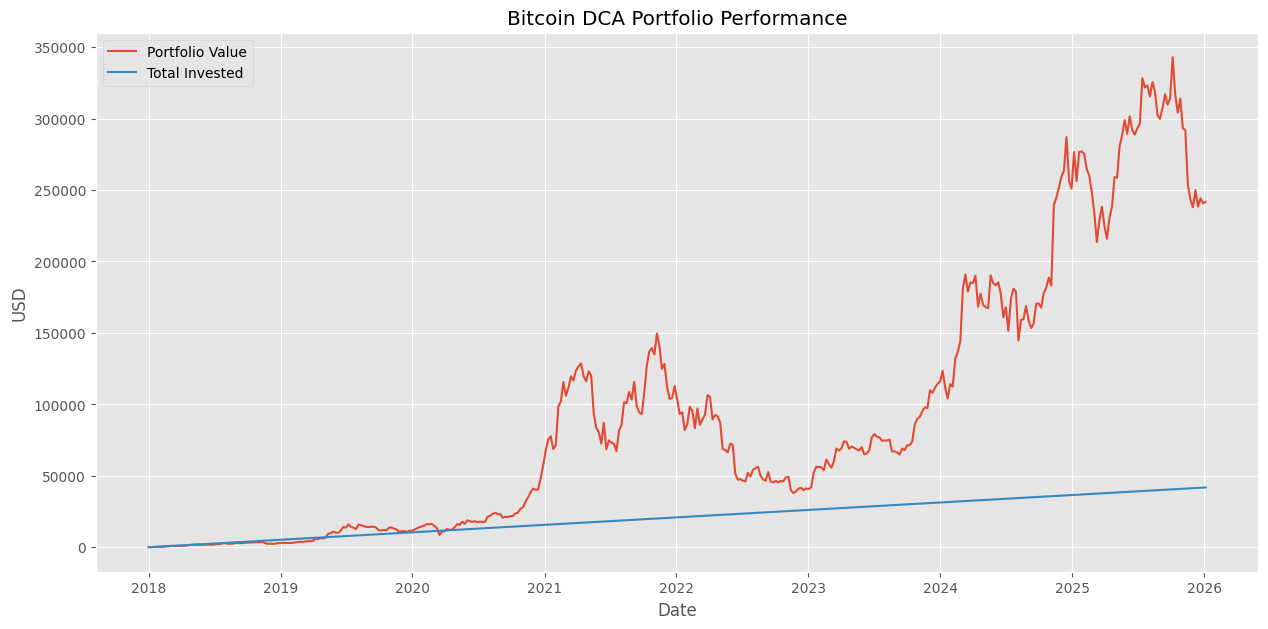

In [25]:
# Plot portfolio growth
plt.figure(figsize=(15,7))

# Portfolio market value
plt.plot(
    dca.index,
    dca["Portfolio_Value"],
    label="Portfolio Value"
)

# Total contributions
plt.plot(
    dca.index,
    dca["Total_Invested"],
    label="Total Invested"
)

# Chart formatting
plt.title("Bitcoin DCA Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()

plt.show()

### Calculate Performance Metrics

Here we summarize the strategy performance: total invested, final portfolio value, total profit, and return on investment (ROI).

ROI measures how much profit was generated relative to invested capital.

In [26]:
# Get last row of simulation
final = dca.iloc[-1]

# Extract important values
total_invested = final["Total_Invested"]
portfolio_value = final["Portfolio_Value"]

# Calculate profit
profit = portfolio_value - total_invested

# Calculate ROI percentage
roi = (
    profit / total_invested
) * 100

# Display results
print(f"Total Invested: ${total_invested:,.2f}")
print(f"Portfolio Value: ${portfolio_value:,.2f}")
print(f"Profit: ${profit:,.2f}")
print(f"ROI: {roi:.2f}%")

Total Invested: $41,900.00
Portfolio Value: $241,724.62
Profit: $199,824.62
ROI: 476.91%


### Add Moving Averages

Moving averages smooth price data to help identify trends.
We calculate:
- 50-day moving average
- 200-day moving average
These are commonly used indicators in trading and technical analysis.

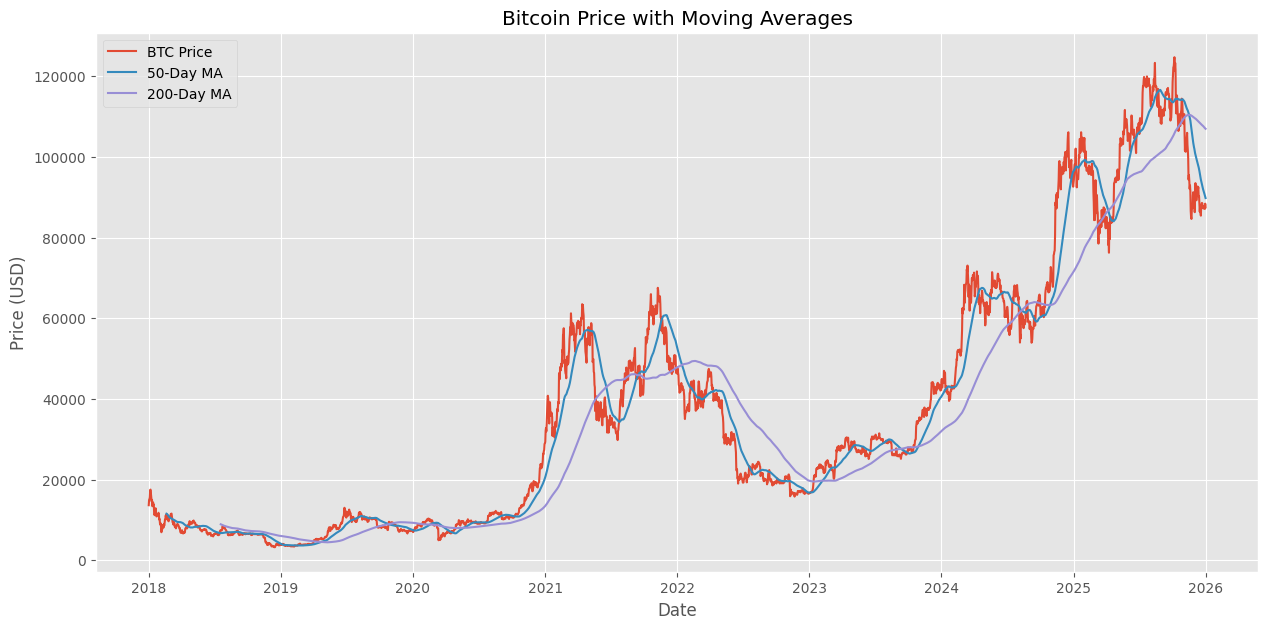

In [27]:
# Calculate moving averages
btc["MA50"] = btc["Close"].rolling(50).mean()
btc["MA200"] = btc["Close"].rolling(200).mean()

# Plot price and moving averages
plt.figure(figsize=(15,7))

# BTC price
plt.plot(
    btc.index,
    btc["Close"],
    label="BTC Price"
)

# 50-day moving average
plt.plot(
    btc.index,
    btc["MA50"],
    label="50-Day MA"
)

# 200-day moving average
plt.plot(
    btc.index,
    btc["MA200"],
    label="200-Day MA"
)

# Labels and formatting
plt.title("Bitcoin Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()

### Interactive Candlestick Chart

Candlestick charts are widely used in financial analysis.
Each candle shows: opening price, closing price, highest price, lowest price.

This gives more market detail than a simple line chart.

In [29]:
# Create interactive candlestick chart
fig = go.Figure(data=[
    go.Candlestick(
        x=btc.index,
        open=btc['Open'],
        high=btc['High'],
        low=btc['Low'],
        close=btc['Close']
    )
])

# Add chart title
fig.update_layout(
    title="Bitcoin Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="BTC Price (USD)"
)

fig.show()